<a href="https://colab.research.google.com/github/Givi-Modebadze/ML_Final_Project/blob/main/experiments/old_LightGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

FOLDERNAME = 'ML_Final_Project/walmart-recruiting-store-sales-forecasting'
assert FOLDERNAME is not None, "[!] Enter the foldername."

import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

%cd /content/drive/My\ Drive/$FOLDERNAME/

Mounted at /content/drive
/content/drive/My Drive/ML_Final_Project/walmart-recruiting-store-sales-forecasting


In [22]:
import numpy as np
import pandas as pd

df = pd.read_csv('train.csv')
stores = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv')
df = df.merge(stores, how='left', left_on='Store', right_on='Store')
df = df.merge(features, how='left', left_on=['Store','Date'], right_on=['Store','Date'])
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [23]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['Quarter'] = df['Date'].dt.quarter
df['DayOfYear'] = df['Date'].dt.dayofyear

In [24]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
for col in markdown_cols:
    df[col] = df[col].fillna(0)

In [25]:
df['CPI'] = df['CPI'].fillna(df['CPI'].median())
df['Unemployment'] = df['Unemployment'].fillna(df['Unemployment'].median())

In [26]:
df['IsHoliday_y'] = df['IsHoliday_y'].astype(int)

df['IsSuperbowl'] = df['Date'].dt.strftime('%Y-%m-%d').isin([
    '2010-02-12', '2011-02-11', '2012-02-10'
]).astype(int)

df['IsLaborDay'] = df['Date'].dt.strftime('%Y-%m-%d').isin([
    '2010-09-10', '2011-09-09', '2012-09-07'
]).astype(int)

df['IsThanksgiving'] = df['Date'].dt.strftime('%Y-%m-%d').isin([
    '2010-11-26', '2011-11-25', '2012-11-23'
]).astype(int)

df['IsChristmas'] = df['Date'].dt.strftime('%Y-%m-%d').isin([
    '2010-12-31', '2011-12-30', '2012-12-28'
]).astype(int)

In [27]:
df = df.sort_values(['Store', 'Dept', 'Date'])

In [28]:
df['Sales_Rolling_Mean_4'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(
    lambda x: x.rolling(4, min_periods=1).mean()
)
df['Sales_Rolling_Std_4'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(
    lambda x: x.rolling(4, min_periods=1).std()
)

In [29]:
from sklearn.preprocessing import LabelEncoder

le_type = LabelEncoder()
df['Type_encoded'] = le_type.fit_transform(df['Type'])

df['Store_Dept'] = df['Store'] * 100 + df['Dept']

In [30]:
dept_stats = df.groupby('Dept')['Weekly_Sales'].agg(['mean', 'std']).reset_index()
dept_stats.columns = ['Dept', 'Dept_Sales_Mean', 'Dept_Sales_Std']
df = df.merge(dept_stats, on='Dept', how='left')

store_stats = df.groupby('Store')['Weekly_Sales'].agg(['mean', 'std']).reset_index()
store_stats.columns = ['Store', 'Store_Sales_Mean', 'Store_Sales_Std']
df = df.merge(store_stats, on='Store', how='left')
df = df.rename(columns={'IsHoliday_y': 'IsHoliday'})

In [31]:
feature_cols = [
    'Store', 'Dept', 'Size', 'Type_encoded', 'Store_Dept',
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
    'Year', 'Month', 'Week', 'Quarter', 'DayOfYear',
    'IsHoliday', 'IsSuperbowl', 'IsLaborDay', 'IsThanksgiving', 'IsChristmas',
    'Sales_Rolling_Mean_4', 'Sales_Rolling_Std_4',
    'Dept_Sales_Mean', 'Dept_Sales_Std',
    'Store_Sales_Mean', 'Store_Sales_Std'
]

In [32]:
X = df[feature_cols]
y = df['Weekly_Sales']

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

def weighted_mae(y_true, y_pred, is_holiday):
    weights = is_holiday * 4 + 1
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

def cross_validation(pipeline, X, y, df_with_dates):
    from matplotlib.dates import DateFormatter

    tscv = TimeSeriesSplit(n_splits=8)
    rmse_scores = []
    wmae_scores = []
    train_rmse_scores = []
    train_wmae_scores = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        if fold < 4:
          continue

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipeline.fit(X_train, y_train)

        # Predictions
        y_val_pred = pipeline.predict(X_val)
        y_train_pred = pipeline.predict(X_train)

        # RMSE
        val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

        # WMAE
        val_is_holiday = df_with_dates.iloc[val_idx]['IsHoliday'].astype(int)
        train_is_holiday = df_with_dates.iloc[train_idx]['IsHoliday'].astype(int)

        val_wmae = weighted_mae(y_val, y_val_pred, val_is_holiday)
        train_wmae = weighted_mae(y_train, y_train_pred, train_is_holiday)

        print(f"\nFold {fold + 1} Scores:")
        print(f"Train RMSE: {train_rmse:.2f} | Train WMAE: {train_wmae:.2f}")
        print(f"Valid RMSE: {val_rmse:.2f} | Valid WMAE: {val_wmae:.2f}")

        rmse_scores.append(val_rmse)
        wmae_scores.append(val_wmae)
        train_rmse_scores.append(train_rmse)
        train_wmae_scores.append(train_wmae)

        # --- Plotting ---
        df_all = pd.DataFrame({
            'Date': pd.to_datetime(df_with_dates['Date']),
            'y': y.values
        })
        df_all = df_all.groupby('Date').sum().reset_index().sort_values('Date')

        df_val = pd.DataFrame({
            'Date': pd.to_datetime(df_with_dates.iloc[val_idx]['Date']),
            'Actual': y_val.values,
            'Predicted': y_val_pred
        }).groupby('Date').sum().reset_index().sort_values('Date')

        df_train = pd.DataFrame({
            'Date': pd.to_datetime(df_with_dates.iloc[train_idx]['Date']),
            'Actual': y_train.values,
            'Predicted': y_train_pred
        }).groupby('Date').sum().reset_index().sort_values('Date')

        plt.figure(figsize=(12, 4))

        # Train actuals
        plt.plot(df_all['Date'], df_all['y'], color='gray', label='Train Actuals', linewidth=1.5, alpha=0.4)

        # Train predictions
        plt.plot(df_train['Date'], df_train['Predicted'], color='green', label='Train Predicted', linewidth=1.5, alpha=0.8)

        # Validation actuals
        plt.plot(df_val['Date'], df_val['Actual'], color='blue', label='Val Actuals', linewidth=2)

        # Validation predictions
        plt.plot(df_val['Date'], df_val['Predicted'], color='orange', label='Val Predicted', linewidth=2)

        plt.title(f'Fold {fold + 1} - Weekly Sales Over Time', fontsize=14)
        plt.xlabel("Date")
        plt.ylabel("Weekly Sales")
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # --- Averages ---
    print(f"\nMean Train RMSE: {np.mean(train_rmse_scores):.2f}")
    print(f"Mean Train WMAE: {np.mean(train_wmae_scores):.2f}")
    print(f"Mean Valid RMSE: {np.mean(rmse_scores):.2f}")
    print(f"Mean Valid WMAE: {np.mean(wmae_scores):.2f}")



Fold 5 Scores:
Train RMSE: 3443.94 | Train WMAE: 1818.35
Valid RMSE: 3781.12 | Valid WMAE: 1935.25


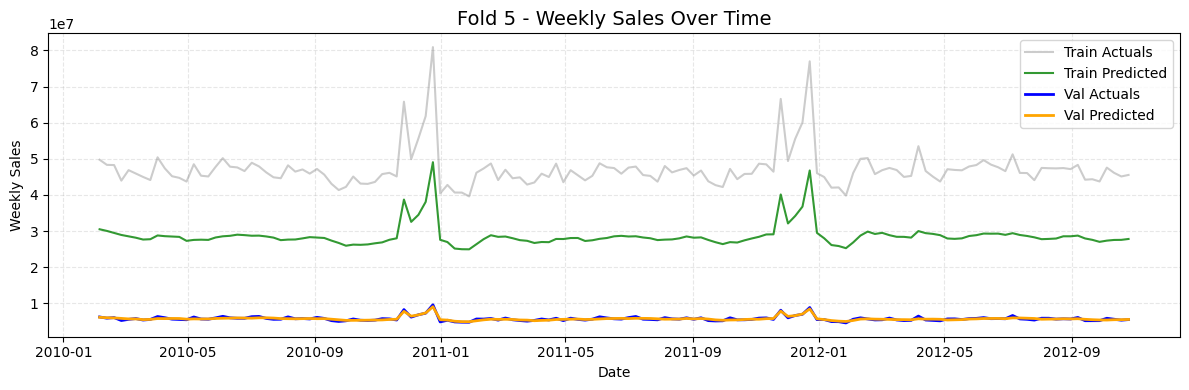


Fold 6 Scores:
Train RMSE: 3474.86 | Train WMAE: 1828.87
Valid RMSE: 2467.63 | Valid WMAE: 1369.70


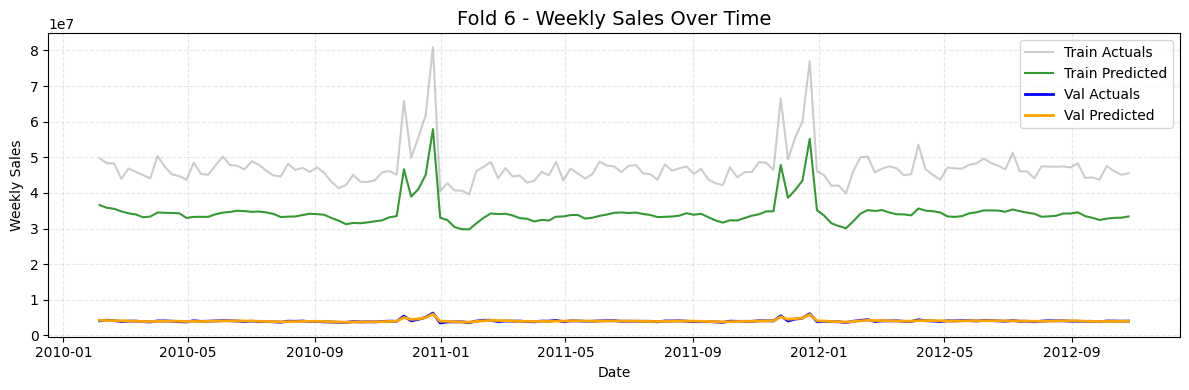


Fold 7 Scores:
Train RMSE: 3338.94 | Train WMAE: 1755.18
Valid RMSE: 2994.34 | Valid WMAE: 1455.15


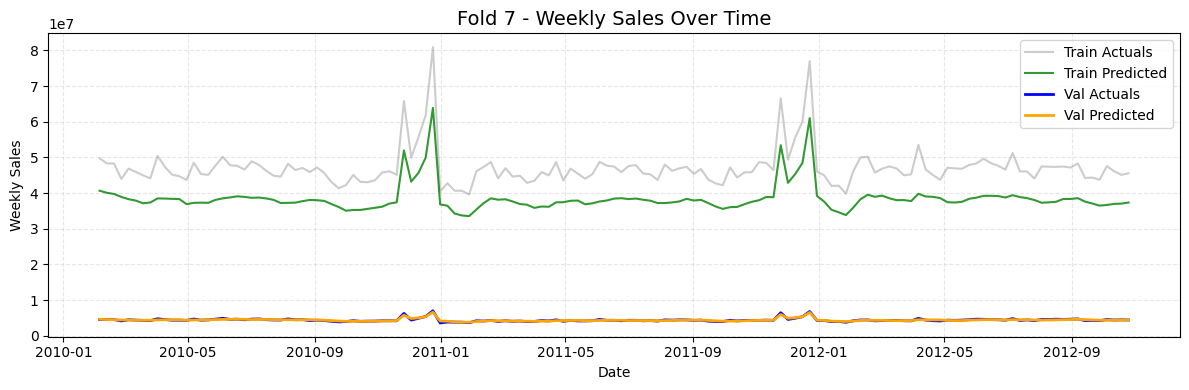


Fold 8 Scores:
Train RMSE: 3276.08 | Train WMAE: 1701.79
Valid RMSE: 2544.20 | Valid WMAE: 1360.30


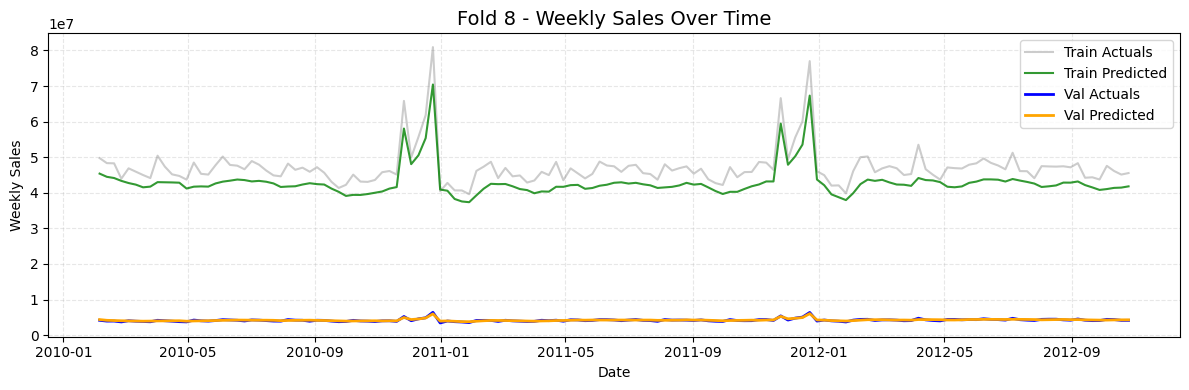


Mean Train RMSE: 3383.45
Mean Train WMAE: 1776.05
Mean Valid RMSE: 2946.82
Mean Valid WMAE: 1530.10


In [34]:
from sklearn.pipeline import Pipeline
from lightgbm import LGBMRegressor

params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1
}
model = LGBMRegressor(**params)

pipeline = Pipeline([
    ('model', model)
])

cross_validation(pipeline, X, y, df)

In [35]:
pipeline.fit(X, y)

Pipeline(steps=[('model',
                 LGBMRegressor(bagging_fraction=0.8, bagging_freq=5,
                               feature_fraction=0.9, learning_rate=0.05,
                               metric='mae', objective='regression',
                               random_state=42, reg_alpha=0.1, reg_lambda=0.1,
                               verbose=-1))])

In [36]:
!pip install dagshub
!pip install "mlflow<3"

import mlflow
import dagshub

dagshub.init(repo_owner='gbend22', repo_name='ML_Final_Project', mlflow=True)

experiment = "Final Project Old Light GBM"
mlflow.set_experiment(experiment)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.0/261.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.9/13.9 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=507903f9-19c2-461d-b89f-55a78a96074d&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=195d8a28a30fcd9fc8a1fb9a9e6d93f73cb8016e20eda72ae65e1c10f585ff9e




Accessing as gbend22

Initialized MLflow to track repo "gbend22/ML_Final_Project"

Repository gbend22/ML_Final_Project initialized!

2025/07/17 08:05:47 INFO mlflow.tracking.fluent: Experiment with name 'Final Project Old Light GBM' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/f089bd8abfb749e9918d4d84390a3149', creation_time=1752739546988, experiment_id='2', last_update_time=1752739546988, lifecycle_stage='active', name='Final Project Old Light GBM', tags={}>

In [37]:
with mlflow.start_run(run_name="basic lightgbm") as run:
    mlflow.sklearn.log_model(
        sk_model=pipeline,
        artifact_path="Old_LightGBM_pipeline_model",
        registered_model_name="LightGBMPipelineModel"
    )

    mlflow.log_params({
        'num_leaves': 31,
        'learning_rate': 0.05,
        'feature_fraction': 0.9,
        'bagging_fraction': 0.8,
        "random_state": 42
    })

    mlflow.log_metrics({
        "Mean Train RMSE" : 3383.45,
        "Mean Train WMAE" : 1776.05,
        "Mean Valid RMSE" : 2946.82,
        "Mean Valid WMAE" : 1530.10,
    })

2025/07/17 08:08:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Successfully registered model 'LightGBMPipelineModel'.
2025/07/17 08:08:59 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: LightGBMPipelineModel, version 1
Created version '1' of model 'LightGBMPipelineModel'.


🏃 View run basic lightgbm at: https://dagshub.com/gbend22/ML_Final_Project.mlflow/#/experiments/2/runs/f845ae7564f04412b210958807146cf2
🧪 View experiment at: https://dagshub.com/gbend22/ML_Final_Project.mlflow/#/experiments/2
